# 04 -- Statistical Analysis

**Project:** SuperStore Retail Performance & Profitability Analysis  
**Workflow:** Hypothesis testing on the cleaned Tableau dataset  
**Goal:** Validate whether the observed dashboard patterns are statistically meaningful and worth emphasizing in Tableau.

## 1. Environment Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "SuperStore_Analysis/Tableau_Analysis/scripts/superstore_pipeline.py").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root from the notebook environment.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from SuperStore_Analysis.Tableau_Analysis.scripts.superstore_pipeline import (
    FINAL_SCHEMA,
    LOYAL_CUSTOMER_MIN_PURCHASES,
    build_clean_dataset,
    build_tableau_ready_dataset,
    compute_project_metrics,
    copy_raw_snapshot,
    export_pipeline_outputs,
    load_existing_cleaned_dataset,
    load_raw_dataset,
    prepare_analysis_frame,
    resolve_project_paths,
    validate_final_schema,
)

PATHS = resolve_project_paths(REPO_ROOT / "SuperStore_Analysis" / "Tableau_Analysis")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

from scipy import stats


## 2. Load the Analysis Frame

In [2]:
df = pd.read_csv(PATHS.cleaned_output_path)
df = prepare_analysis_frame(df)
display(df.head(5))


,Row ID,Transaction Id (PK),Order ID,Order Date,Year,Month,Quarter,Ship Date,Shipping Delay,Shipping Speed,Ship Mode,Customer ID,Customer Name,Customer Type,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Order-Size,Sales Per Unit,Discount,Profit,Profit Margin,Loss Severity,Loss Flag,Order-Level Total Sales (Grouped by Order ID C),Customer Purchase Frequency (Customer ID = L),Total sales per customer,Discount Amount (Sales × Discount),Order Date Parsed,Ship Date Parsed,Month Number,Quarter Number,Year Quarter,Year Quarter Sort,Discount Rate,Profit Margin %,Loss Indicator,High Discount Indicator,Profit Only,Loss Only,Absolute Loss,Discount Band
0,1,TXN-000001,CA-2016-152156,11/8/2016,2016,November,Q4,11/11/2016,3,Fast,Second Class,CG-12520,Claire Gute,Occasional,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,FURNITURE,Bookcases,Bush Somerset Collection Bookcase,261.96,2,Medium,130.98,0%,41.91,0.16,Profit,Profit,993.90,5,"1,148.78",0.00,2016-11-08,2016-11-11,11,4,2016 Q4,20164,0.00,16.00,0,0,41.91,0.00,0.00,No Discount
1,2,TXN-000002,CA-2016-152156,11/8/2016,2016,November,Q4,11/11/2016,3,Fast,Second Class,CG-12520,Claire Gute,Occasional,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,FURNITURE,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,Large,243.98,0%,219.58,0.30,Profit,Profit,993.90,5,"1,148.78",0.00,2016-11-08,2016-11-11,11,4,2016 Q4,20164,0.00,30.00,0,0,219.58,0.00,0.00,No Discount
2,3,TXN-000003,CA-2016-138688,6/12/2016,2016,June,Q2,6/16/2016,4,Normal,Second Class,DV-13045,Darrin Van Huff,Occasional,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,OFFICE SUPPLIES,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,Small,7.31,0%,6.87,0.47,Profit,Profit,14.62,9,"1,119.48",0.00,2016-06-12,2016-06-16,6,2,2016 Q2,20162,0.00,47.00,0,0,6.87,0.00,0.00,No Discount
3,4,TXN-000004,US-2015-108966,10/11/2015,2015,October,Q4,10/18/2015,7,Slow,Standard Class,SO-20335,Sean O'Donnell,Loyal,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,FURNITURE,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,Large,191.52,45%,-383.03,-0.40,High Loss,Loss,979.95,15,"2,602.58",430.91,2015-10-11,2015-10-18,10,4,2015 Q4,20154,0.45,-40.00,1,1,0.00,-383.03,383.03,Deep Discount
4,5,TXN-000005,US-2015-108966,10/11/2015,2015,October,Q4,10/18/2015,7,Slow,Standard Class,SO-20335,Sean O'Donnell,Loyal,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,OFFICE SUPPLIES,Storage,Eldon Fold 'N Roll Cart System,22.37,2,Small,11.18,20%,2.52,0.11,Profit,Profit,979.95,15,"2,602.58",4.47,2015-10-11,2015-10-18,10,4,2015 Q4,20154,0.20,11.00,0,0,2.52,0.00,0.00,Moderate Discount


## 3. Correlation Analysis

,Sales,Quantity,Shipping Delay,Discount Rate,Profit,Profit Margin
Sales,1.00,0.20,-0.01,-0.03,0.48,0.00
Quantity,0.20,1.00,0.02,0.01,0.07,-0.01
Shipping Delay,-0.01,0.02,1.00,0.00,-0.01,-0.01
Discount Rate,-0.03,0.01,0.00,1.00,-0.22,-0.86
Profit,0.48,0.07,-0.01,-0.22,1.00,0.22
Profit Margin,0.00,-0.01,-0.01,-0.86,0.22,1.00


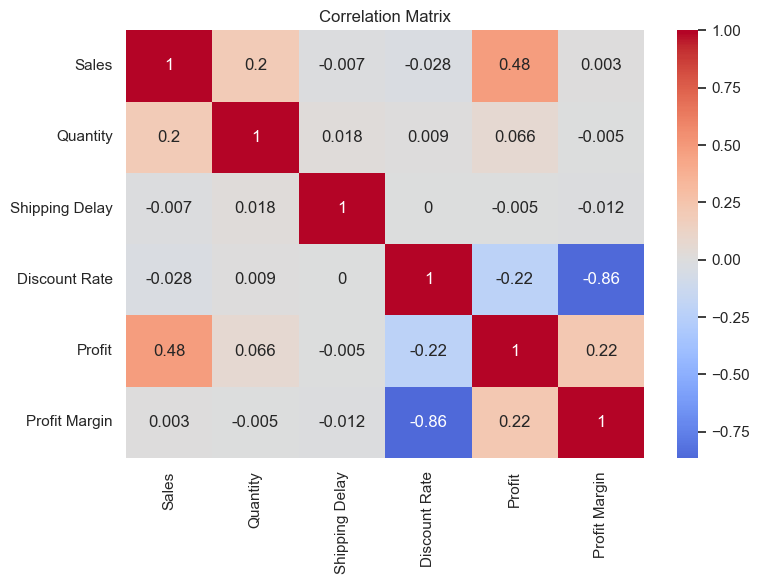

In [3]:
numeric_cols = ['Sales', 'Quantity', 'Shipping Delay', 'Discount Rate', 'Profit', 'Profit Margin']
corr = df[numeric_cols].corr().round(3)
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


## 4. Discount vs Profit Margin Relationship

,Statistic,Value
0,Pearson correlation,-0.86
1,p-value,0.00


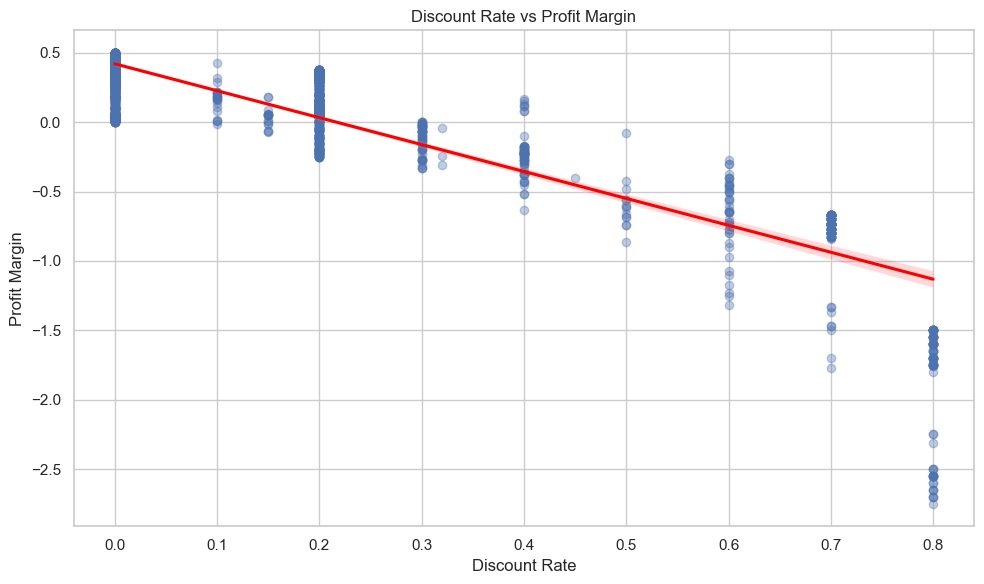

In [4]:
pearson_r, pearson_p = stats.pearsonr(df['Discount Rate'], df['Profit Margin'])
pearson_table = pd.DataFrame({
    'Statistic': ['Pearson correlation', 'p-value'],
    'Value': [round(pearson_r, 4), pearson_p],
})
display(pearson_table)

plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(min(len(df), 3000), random_state=42), x='Discount Rate', y='Profit Margin', scatter_kws={'alpha': 0.35}, line_kws={'color': 'red'})
plt.title('Discount Rate vs Profit Margin')
plt.tight_layout()
plt.show()


## 5. High-Discount vs Lower-Discount Profit Test

In [5]:
high_discount_profit = df.loc[df['Discount Rate'] > 0.20, 'Profit']
low_discount_profit = df.loc[df['Discount Rate'] <= 0.20, 'Profit']

t_stat, p_value = stats.ttest_ind(high_discount_profit, low_discount_profit, equal_var=False)
comparison = pd.DataFrame({
    'Group': ['Discount > 20%', 'Discount <= 20%'],
    'Mean Profit': [high_discount_profit.mean(), low_discount_profit.mean()],
    'Median Profit': [high_discount_profit.median(), low_discount_profit.median()],
    'Row Count': [len(high_discount_profit), len(low_discount_profit)],
}).round(2)
display(comparison)
display(pd.DataFrame({'Statistic': ['Welch t-statistic', 'p-value'], 'Value': [round(t_stat, 4), p_value]}))


,Group,Mean Profit,Median Profit,Row Count
0,Discount > 20%,-97.24,-18.35,1392
1,Discount <= 20%,49.04,11.54,8601


,Statistic,Value
0,Welch t-statistic,-16.14
1,p-value,0.00


## 6. Category-Level Profit Differences

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
FURNITURE,"2,120.00",8.71,136.08,"-1,862.31",-12.86,7.78,33.76,"1,013.13"
OFFICE SUPPLIES,"6,026.00",20.33,164.89,"-3,701.89",2.10,6.88,19.42,"4,946.37"
TECHNOLOGY,"1,847.00",78.75,428.82,"-6,599.98",5.20,25.02,74.89,"8,399.98"


,Statistic,Value
0,ANOVA F-statistic,54.30
1,p-value,0.00


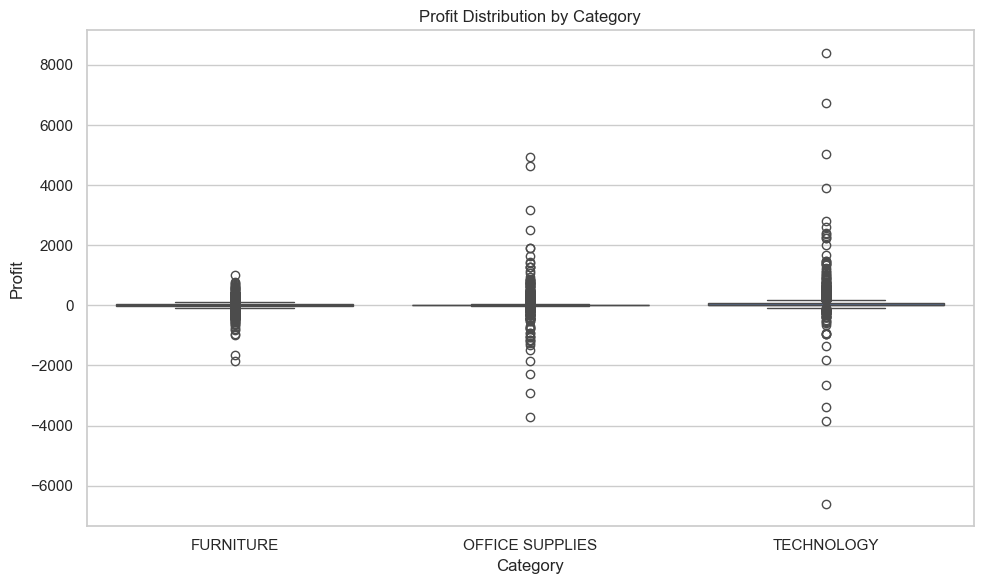

In [6]:
anova_result = stats.f_oneway(*(group['Profit'] for _, group in df.groupby('Category')))
category_profit = df.groupby('Category')['Profit'].describe().round(2)
display(category_profit)
display(pd.DataFrame({'Statistic': ['ANOVA F-statistic', 'p-value'], 'Value': [round(anova_result.statistic, 4), anova_result.pvalue]}))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Category')
plt.tight_layout()
plt.show()


## 7. Discount Band vs Loss Outcome

In [7]:
contingency = pd.crosstab(df['Discount Band'], df['Loss Flag'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
display(contingency)
display(pd.DataFrame({'Statistic': ['Chi-square', 'p-value', 'Degrees of freedom'], 'Value': [round(chi2, 4), p_value, dof]}))

loss_rate = pd.crosstab(df['Discount Band'], df['Loss Flag'], normalize='index').mul(100).round(2)
display(loss_rate)


Loss Flag,Loss,Profit
Discount Band,,
Deep Discount,933,0
High Discount,414,45
Low Discount,4,90
Moderate Discount,519,3190
No Discount,0,4798


,Statistic,Value
0,Chi-square,"6,766.49"
1,p-value,0.00
2,Degrees of freedom,4.00


Loss Flag,Loss,Profit
Discount Band,,
Deep Discount,100.00,0.00
High Discount,90.20,9.80
Low Discount,4.26,95.74
Moderate Discount,13.99,86.01
No Discount,0.00,100.00


## 8. Statistical Takeaways

- Discount rate and profit margin show a strong negative relationship.
- Profit outcomes for transactions above 20% discount differ materially from the rest of the dataset.
- Category-level profit patterns are not random; they are statistically distinct.
- Loss incidence is highly dependent on discount band, which supports a dedicated discount-risk page in Tableau.